In [1]:
!pip install -q ultralytics==8.4.80

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 66.9 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires nu

In [2]:
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from pathlib import Path

TEST_IMAGE_DIR = Path(
    "/kaggle/input/datasets/gibranariq/final-project/final_project.yolo/test/images"
)

test_images = sorted(TEST_IMAGE_DIR.glob("*"))

print(f"Total test images: {len(test_images)}")

Total test images: 404


In [4]:
MODELS = {
    "YOLO11s Baseline": "/kaggle/input/models/gibranariq/drowsiness-detection-model/other/default/1/yolo11_baseline.pt",
    "YOLO11s V2": "/kaggle/input/models/gibranariq/drowsiness-detection-model/other/default/1/yolo11_v2.pt",
    "YOLO11s V3": "/kaggle/input/models/gibranariq/drowsiness-detection-model/other/default/1/yolo11_v3.pt",
    "YOLO26s Baseline": "/kaggle/input/models/gibranariq/drowsiness-detection-model/other/default/1/yolo26_baseline.pt",
    "YOLO26s V2": "/kaggle/input/models/gibranariq/drowsiness-detection-model/other/default/1/yolo26_v2.pt",
    "YOLO26s V3": "/kaggle/input/models/gibranariq/drowsiness-detection-model/other/default/1/yolo26_v3.pt",
}

In [5]:
def benchmark_inference(model_path, images, imgsz=640, device=0, warmup=10):
    model = YOLO(model_path)

    # warmup, tidak dihitung
    for img in images[:warmup]:
        _ = model.predict(str(img), imgsz=imgsz, device=device, verbose=False)

    times = []
    for img in images:
        start = time.perf_counter()
        _ = model.predict(str(img), imgsz=imgsz, device=device, verbose=False)
        end = time.perf_counter()
        times.append(end - start)

    avg_time = sum(times) / len(times)
    fps = 1 / avg_time

    return avg_time, fps

In [6]:
import time

results = []

for model_name, model_path in MODELS.items():
    print(f"Benchmarking {model_name}...")

    avg_time, fps = benchmark_inference(
        model_path=model_path,
        images=test_images,
        imgsz=640,
        device=0
    )

    results.append({
        "Model": model_name,
        "Inference Time (s)": avg_time,
        "Inference Time (ms)": avg_time * 1000,
        "FPS": fps
    })

benchmark_df = pd.DataFrame(results)
benchmark_df

Benchmarking YOLO11s Baseline...
Benchmarking YOLO11s V2...
Benchmarking YOLO11s V3...
Benchmarking YOLO26s Baseline...
Benchmarking YOLO26s V2...
Benchmarking YOLO26s V3...


,Model,Inference Time (s),Inference Time (ms),FPS
0,YOLO11s Baseline,0.026134,26.134173,38.264077
1,YOLO11s V2,0.014637,14.636851,68.320708
2,YOLO11s V3,0.014735,14.735225,67.864590
3,YOLO26s Baseline,0.014862,14.861691,67.287094
4,YOLO26s V2,0.015060,15.059622,66.402728
5,YOLO26s V3,0.014763,14.763426,67.734955


In [7]:
for name, path in MODELS.items():
    model = YOLO(path)

    params = sum(p.numel() for p in model.model.parameters())
    size = Path(path).stat().st_size / (1024**2)

    print(f"{name}")
    print(f"Size   : {size:.2f} MB")
    print(f"Params : {params:,}")
    print("-"*40)

YOLO11s Baseline
Size   : 18.30 MB
Params : 9,428,566
----------------------------------------
YOLO11s V2
Size   : 18.30 MB
Params : 9,428,566
----------------------------------------
YOLO11s V3
Size   : 18.30 MB
Params : 9,428,566
----------------------------------------
YOLO26s Baseline
Size   : 19.38 MB
Params : 9,949,412
----------------------------------------
YOLO26s V2
Size   : 19.39 MB
Params : 9,949,412
----------------------------------------
YOLO26s V3
Size   : 19.39 MB
Params : 9,949,412
----------------------------------------


In [9]:
from ultralytics import YOLO
from pathlib import Path
from time import perf_counter
import torch

# Configuration
MODEL_PATH = "/kaggle/input/models/gibranariq/drowsiness-detection-model/other/default/1/yolo11_baseline.pt"  # Ganti sesuai path kamu
TEST_IMAGE_DIR = Path("/kaggle/input/datasets/gibranariq/final-project/final_project.yolo/test/images")

DEVICE = 0 if torch.cuda.is_available() else "cpu"
IMG_SIZE = 640
WARMUP = 10

# Load images
test_images = sorted(TEST_IMAGE_DIR.glob("*"))

# Load model
model = YOLO(MODEL_PATH)

# Warmup
for img in test_images[:WARMUP]:
    model.predict(str(img), imgsz=IMG_SIZE, device=DEVICE, verbose=False)

# Benchmark
times = []

for img in test_images:
    start = perf_counter()
    model.predict(str(img), imgsz=IMG_SIZE, device=DEVICE, verbose=False)
    end = perf_counter()

    times.append(end - start)

avg_time = sum(times) / len(times)
fps = 1 / avg_time

print(f"Average Inference Time : {avg_time * 1000:.2f} ms")
print(f"FPS                   : {fps:.2f}")

Average Inference Time : 15.08 ms
FPS                   : 66.32


In [10]:
for i in range(5):
    times = []

    for img in test_images:
        start = perf_counter()
        model.predict(str(img), imgsz=IMG_SIZE, device=DEVICE, verbose=False)
        end = perf_counter()

        times.append(end - start)

    avg = sum(times) / len(times)

    print(
        f"Run {i+1}: "
        f"{avg*1000:.2f} ms | "
        f"{1/avg:.2f} FPS"
    )

Run 1: 15.30 ms | 65.36 FPS
Run 2: 14.18 ms | 70.52 FPS
Run 3: 14.22 ms | 70.32 FPS
Run 4: 14.25 ms | 70.17 FPS
Run 5: 14.19 ms | 70.49 FPS


In [11]:
import random
import pandas as pd

all_results = []

for repeat in range(5):
    print(f"\nRepeat {repeat + 1}/5")

    model_items = list(MODELS.items())
    random.shuffle(model_items)

    for model_name, model_path in model_items:
        print(f"Benchmarking {model_name}...")

        avg_time, fps = benchmark_inference(
            model_path=model_path,
            images=test_images,
            imgsz=IMG_SIZE,
            device=DEVICE,
            warmup=WARMUP
        )

        all_results.append({
            "Repeat": repeat + 1,
            "Model": model_name,
            "Inference Time (ms)": avg_time * 1000,
            "FPS": fps
        })

raw_benchmark_df = pd.DataFrame(all_results)

benchmark_summary_df = raw_benchmark_df.groupby("Model").agg(
    Mean_Inference_Time_ms=("Inference Time (ms)", "mean"),
    Std_Inference_Time_ms=("Inference Time (ms)", "std"),
    Mean_FPS=("FPS", "mean"),
    Std_FPS=("FPS", "std")
).reset_index()

benchmark_summary_df


Repeat 1/5
Benchmarking YOLO11s V2...
Benchmarking YOLO11s Baseline...
Benchmarking YOLO26s V2...
Benchmarking YOLO26s Baseline...
Benchmarking YOLO11s V3...
Benchmarking YOLO26s V3...

Repeat 2/5
Benchmarking YOLO26s Baseline...
Benchmarking YOLO11s V2...
Benchmarking YOLO26s V3...
Benchmarking YOLO26s V2...
Benchmarking YOLO11s Baseline...
Benchmarking YOLO11s V3...

Repeat 3/5
Benchmarking YOLO11s V3...
Benchmarking YOLO26s Baseline...
Benchmarking YOLO11s V2...
Benchmarking YOLO26s V2...
Benchmarking YOLO11s Baseline...
Benchmarking YOLO26s V3...

Repeat 4/5
Benchmarking YOLO11s V2...
Benchmarking YOLO26s V2...
Benchmarking YOLO26s Baseline...
Benchmarking YOLO11s Baseline...
Benchmarking YOLO11s V3...
Benchmarking YOLO26s V3...

Repeat 5/5
Benchmarking YOLO26s Baseline...
Benchmarking YOLO26s V3...
Benchmarking YOLO26s V2...
Benchmarking YOLO11s Baseline...
Benchmarking YOLO11s V2...
Benchmarking YOLO11s V3...


,Model,Mean_Inference_Time_ms,Std_Inference_Time_ms,Mean_FPS,Std_FPS
0,YOLO11s Baseline,13.994281,0.040449,71.458237,0.206399
1,YOLO11s V2,14.014067,0.087301,71.359082,0.443289
2,YOLO11s V3,14.041227,0.083909,71.220884,0.425774
3,YOLO26s Baseline,14.861927,0.067341,67.287126,0.304164
4,YOLO26s V2,14.864470,0.138946,67.279218,0.629101
5,YOLO26s V3,14.816026,0.146179,67.499734,0.665451


In [15]:
comparison_df = pd.DataFrame({
    "Model": [
        "YOLO11s Baseline",
        "YOLO11s V2",
        "YOLO11s V3",
        "YOLO26s Baseline",
        "YOLO26s V2",
        "YOLO26s V3",
    ],

    "Precision": [
        0.8873,
        0.8676,
        0.8424,
        0.8636,
        0.9130,
        0.9246,
    ],

    "Recall": [
        0.8975,
        0.9500,
        0.8895,
        0.8221,
        0.8960,
        0.8858,
    ],

    "F1 Score": [
        0.8924,
        0.9069,
        0.8653,
        0.8424,
        0.9044,
        0.9048,
    ],

    "mAP50": [
        0.9514,
        0.9619,
        0.9288,
        0.9159,
        0.9485,
        0.9506,
    ],

    "mAP50-95": [
        0.6675,
        0.6209,
        0.5967,
        0.6077,
        0.6561,
        0.6383,
    ],

    "Inference Time (ms)": [
        13.994281,
        14.014067,
        14.041227,
        14.861927,
        14.864470,
        14.816026,
    ],

    "FPS": [
        71.458237,
        71.359082,
        71.220884,
        67.287126,
        67.279218,
        67.499734,
    ],

    "Parameters (Million)": [
        9.43,
        9.43,
        9.43,
        9.95,
        9.95,
        9.95,
    ],

    "Model Size (MB)": [
        18.30,
        18.30,
        18.30,
        19.38,
        19.39,
        19.39,
    ]
})

comparison_df = comparison_df.round(4)

comparison_df

,Model,Precision,Recall,F1 Score,mAP50,mAP50-95,Inference Time (ms),FPS,Parameters (Million),Model Size (MB)
0,YOLO11s Baseline,0.8873,0.8975,0.8924,0.9514,0.6675,13.9943,71.4582,9.43,18.30
1,YOLO11s V2,0.8676,0.9500,0.9069,0.9619,0.6209,14.0141,71.3591,9.43,18.30
2,YOLO11s V3,0.8424,0.8895,0.8653,0.9288,0.5967,14.0412,71.2209,9.43,18.30
3,YOLO26s Baseline,0.8636,0.8221,0.8424,0.9159,0.6077,14.8619,67.2871,9.95,19.38
4,YOLO26s V2,0.9130,0.8960,0.9044,0.9485,0.6561,14.8645,67.2792,9.95,19.39
5,YOLO26s V3,0.9246,0.8858,0.9048,0.9506,0.6383,14.8160,67.4997,9.95,19.39


In [16]:
final_comparison_df = (
    comparison_df
    .drop(columns=["Inference Time (ms)", "FPS"])
    .merge(
        benchmark_summary_df[
            ["Model", "Mean_Inference_Time_ms", "Mean_FPS"]
        ],
        on="Model"
    )
    .rename(columns={
        "Mean_Inference_Time_ms": "Inference Time (ms)",
        "Mean_FPS": "FPS"
    })
)

final_comparison_df = final_comparison_df.round(4)

final_comparison_df

,Model,Precision,Recall,F1 Score,mAP50,mAP50-95,Parameters (Million),Model Size (MB),Inference Time (ms),FPS
0,YOLO11s Baseline,0.8873,0.8975,0.8924,0.9514,0.6675,9.43,18.30,13.9943,71.4582
1,YOLO11s V2,0.8676,0.9500,0.9069,0.9619,0.6209,9.43,18.30,14.0141,71.3591
2,YOLO11s V3,0.8424,0.8895,0.8653,0.9288,0.5967,9.43,18.30,14.0412,71.2209
3,YOLO26s Baseline,0.8636,0.8221,0.8424,0.9159,0.6077,9.95,19.38,14.8619,67.2871
4,YOLO26s V2,0.9130,0.8960,0.9044,0.9485,0.6561,9.95,19.39,14.8645,67.2792
5,YOLO26s V3,0.9246,0.8858,0.9048,0.9506,0.6383,9.95,19.39,14.8160,67.4997


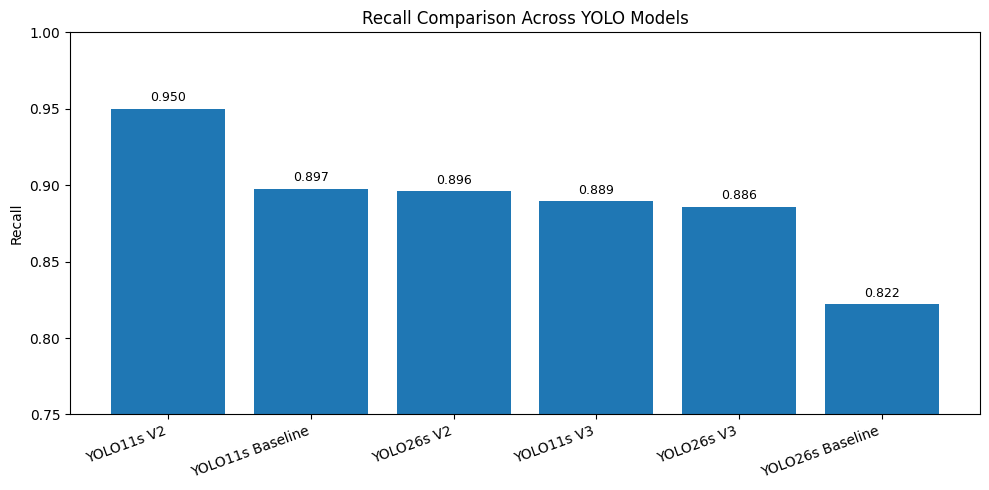

In [20]:
import matplotlib.pyplot as plt

# Sort by recall (optional)
recall_df = comparison_df.sort_values("Recall", ascending=False)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    recall_df["Model"],
    recall_df["Recall"],
)

plt.ylabel("Recall")
plt.title("Recall Comparison Across YOLO Models")
plt.xticks(rotation=20, ha="right")
plt.ylim(0.75, 1.0)

# value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.3f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

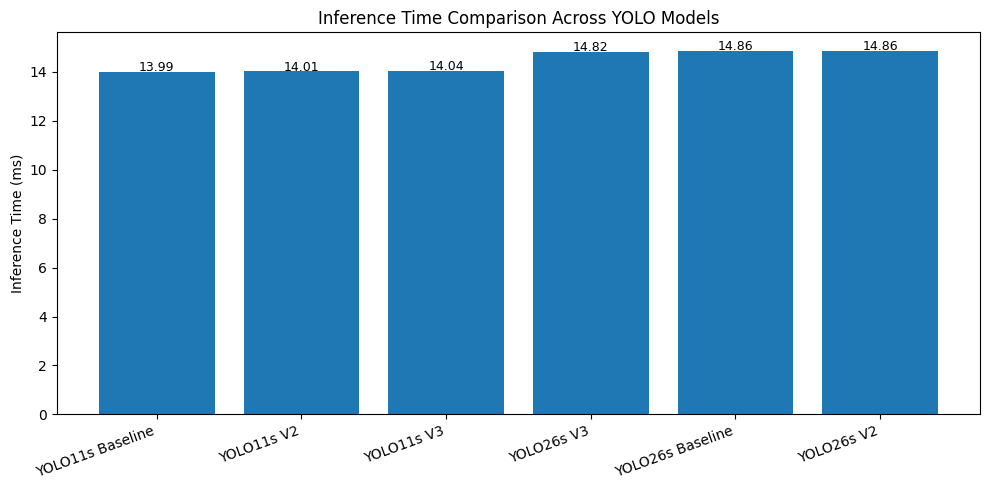

In [19]:
time_df = comparison_df.sort_values("Inference Time (ms)")

plt.figure(figsize=(10,5))

bars = plt.bar(
    time_df["Model"],
    time_df["Inference Time (ms)"],
)

plt.ylabel("Inference Time (ms)")
plt.title("Inference Time Comparison Across YOLO Models")
plt.xticks(rotation=20, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.03,
        f"{height:.2f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

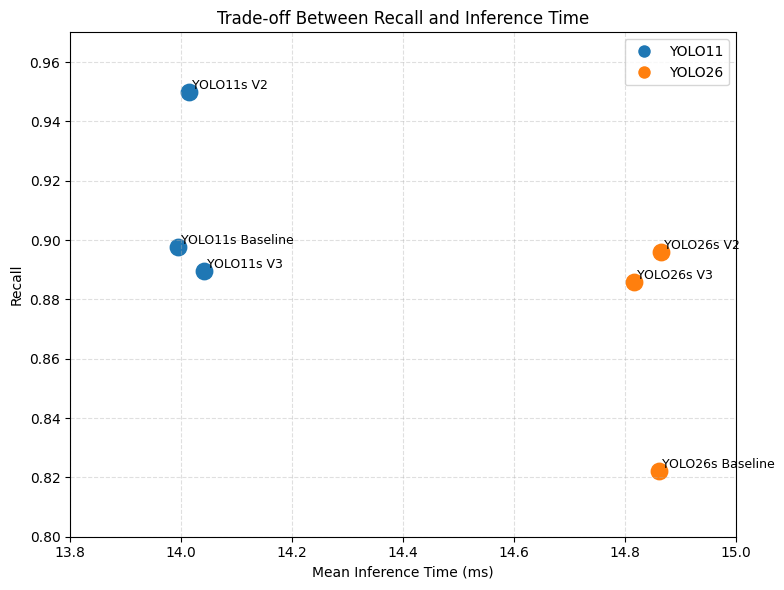

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

colors = {
    "YOLO11": "tab:blue",
    "YOLO26": "tab:orange"
}

for _, row in comparison_df.iterrows():

    color = colors["YOLO11"] if "YOLO11" in row["Model"] else colors["YOLO26"]

    plt.scatter(
        row["Inference Time (ms)"],
        row["Recall"],
        s=140,
        color=color
    )

    plt.text(
        row["Inference Time (ms)"] + 0.005,
        row["Recall"] + 0.001,
        row["Model"],
        fontsize=9
    )

plt.xlabel("Mean Inference Time (ms)")
plt.ylabel("Recall")
plt.title("Trade-off Between Recall and Inference Time")

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='YOLO11',
           markerfacecolor='tab:blue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='YOLO26',
           markerfacecolor='tab:orange', markersize=10),
]

plt.legend(handles=legend_elements)

plt.grid(True, linestyle="--", alpha=0.4)

plt.xlim(13.8,15.0)
plt.ylim(0.80,0.97)

plt.tight_layout()
plt.show()